**Text Preprocessing, Tokenization, and Sequence Padding:**

In [80]:
# Importing the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer
import contractions
from wordcloud import WordCloud
from collections import Counter
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from gensim.models import Word2Vec
import gensim.downloader as api
import gradio as gr
import pickle
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

print("All libraries imported successfully!")

All libraries imported successfully!


**Load the dataset:**

In [81]:
df = pd.read_csv("/content/drive/MyDrive/AI and ML/Coursework/3. Financial Phrase Dataset/financial_phrase.csv")
df.head()

,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


In [82]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2264 entries, 0 to 2263
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2264 non-null   object
 1   label   2264 non-null   object
dtypes: object(2)
memory usage: 35.5+ KB


Index(['text', 'label'], dtype='object')

**Clean the text:**

In [83]:
# Lowercase all text
def lowercase_text(text):
    return text.lower()

df['text_cleaned'] = df['text'].apply(lowercase_text)

In [84]:
# Remove URLs, mentions, hashtags, numbers
def remove_patterns(text):
    text = re.sub(r'http\S+|www\S+|@\w+|#\w+|\d+', '', text)
    return text

df['text_cleaned'] = df['text_cleaned'].apply(remove_patterns)

In [85]:
# Handle contractions
def fix_contractions(text):
    return contractions.fix(text)

df['text_cleaned'] = df['text_cleaned'].apply(fix_contractions)

In [86]:
# Remove emojis
def remove_emoji(text):
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"
                           u"\U0001F300-\U0001F5FF"
                           u"\U0001F680-\U0001F6FF"
                           u"\U0001F1E0-\U0001F1FF"
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r' ', text)

df['text_cleaned'] = df['text_cleaned'].apply(remove_emoji)

In [87]:
# Remove punctuation and special characters
def remove_punct(text):
    tokenizer = RegexpTokenizer(r"\w+")
    tokens = tokenizer.tokenize(text)
    return ' '.join(tokens)

df['text_cleaned'] = df['text_cleaned'].apply(remove_punct)

In [88]:
# Remove stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['text_cleaned'] = df['text_cleaned'].apply(remove_stopwords)

In [89]:
# Lemmatization
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(token, pos='v') for token in tokens]
    return ' '.join(tokens)

df['text_cleaned'] = df['text_cleaned'].apply(lemmatize_text)

In [90]:
df[['text_cleaned']].head()

,text_cleaned
0,accord gran company plan move production russi...
1,last quarter componenta net sales double eurm ...
2,third quarter net sales increase eur mn operat...
3,operate profit rise eur mn eur mn correspond p...
4,operate profit total eur mn eur mn represent n...


**Visualize the cleaned data:**

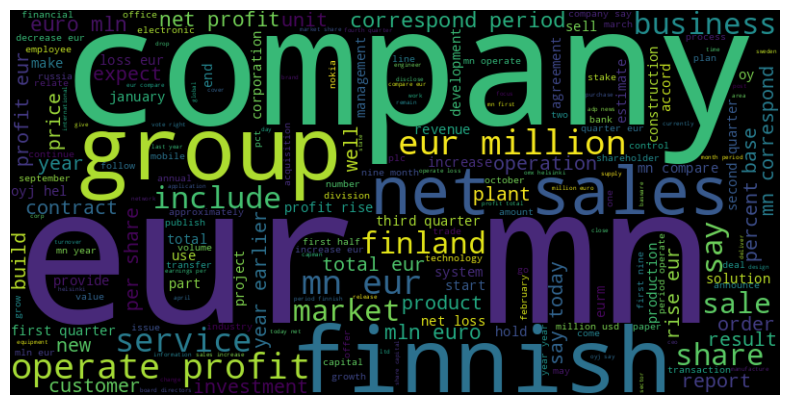

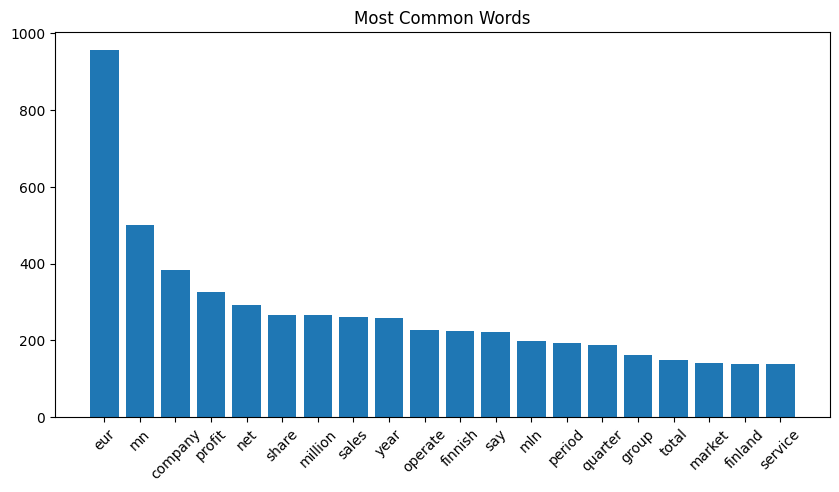

In [91]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

all_words = ' '.join(df['text_cleaned'])
wordcloud = WordCloud(width=800, height=400).generate(all_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

word_freq = Counter(all_words.split())
common_words = word_freq.most_common(20)

words, counts = zip(*common_words)
plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.title('Most Common Words')
plt.xticks(rotation=45)
plt.show()

**Tokenization and Padding:**

In [92]:
# Get text and labels
X = df['text_cleaned'].values
y = df['label'].values

# Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert words to numbers
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Vocabulary size = unique words + 1 for OOV
vocab_size = len(tokenizer.word_index) + 1

# Convert text to number sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Set max length using 99th percentile
lengths = [len(seq) for seq in X_train_seq]
max_len = int(np.percentile(lengths, 99))

# Pad sequences (add zeros at beginning)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='pre')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='pre')

# Convert labels to numbers then to one-hot
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)
y_train_encoded = to_categorical(y_train_enc)
y_test_encoded = to_categorical(y_test_enc)

# Print info
print(f"Vocabulary size: {vocab_size}")
print(f"Max sequence length: {max_len}")
print(f"Training samples: {X_train_pad.shape[0]}")
print(f"Test samples: {X_test_pad.shape[0]}")

Vocabulary size: 4044
Max sequence length: 28
Training samples: 1811
Test samples: 453


**Model Building and Training:**

In [93]:
# Class weights to handle imbalance
classes = np.unique(y_train_enc)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train_enc)
class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(2.443994601889339), np.int64(1): np.float64(0.5414050822122571), np.int64(2): np.float64(1.3444691907943578)}


**Simple RNN**

In [94]:
model1 = Sequential()
model1.add(Embedding(input_dim=vocab_size, output_dim=256, input_length=max_len))
model1.add(SimpleRNN(units=128, return_sequences=False, dropout=0.4))
model1.add(Dropout(0.5))  # Reduce overfitting
model1.add(Dense(units=y_train_encoded.shape[1], activation='softmax'))  # Output layer

# Compile model
model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [95]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [96]:
history1 = model1.fit(
    X_train_pad, y_train_encoded,
    validation_split=0.2, # 20% for validation
    epochs=15,
    batch_size=32,
    class_weight=class_weight_dict,  # Handle class imbalance
    callbacks=[early_stop] # Stop if no improvement
)

Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.4468 - loss: 1.0689 - val_accuracy: 0.6887 - val_loss: 0.8816
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7852 - loss: 0.7141 - val_accuracy: 0.6860 - val_loss: 0.7208
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8985 - loss: 0.3716 - val_accuracy: 0.6804 - val_loss: 0.8418
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9454 - loss: 0.2251 - val_accuracy: 0.6997 - val_loss: 0.8024
Epoch 5/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9627 - loss: 0.1541 - val_accuracy: 0.7163 - val_loss: 0.7615


**LSTM**

In [97]:
model2 = Sequential()
model2.add(Embedding(input_dim=vocab_size, output_dim=256, input_length=max_len))
model2.add(LSTM(units=128, dropout=0.4, recurrent_dropout=0.3))  # LSTM with dropout
model2.add(Dense(units=y_train_encoded.shape[1], activation='softmax'))

model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy']) # Compile model

In [98]:
history2 = model2.fit(
    X_train_pad, y_train_encoded,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 13s 178ms/step - accuracy: 0.6153 - loss: 0.9703 - val_accuracy: 0.7052 - val_loss: 0.7330
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.7949 - loss: 0.7011 - val_accuracy: 0.7961 - val_loss: 0.6060
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - accuracy: 0.8867 - loss: 0.4348 - val_accuracy: 0.8595 - val_loss: 0.4334
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 141ms/step - accuracy: 0.9385 - loss: 0.2298 - val_accuracy: 0.8457 - val_loss: 0.3758
Epoch 5/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.9586 - loss: 0.1566 - val_accuracy: 0.8567 - val_loss: 0.4077
Epoch 6/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 152ms/step - accuracy: 0.9662 - loss: 0.1282 - val_accuracy: 0.8512 - val_loss: 0.4578
Epoch 7/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - accuracy: 0.9724 - loss: 0.1128 - val_accuracy: 0.8320 - val_loss: 0.4499


**LSTM with pretrained Word2Vec**

In [99]:
w2v_model = api.load("word2vec-google-news-300")

embedding_dim = 300
print("Model loaded successfully!")

Model loaded successfully!


In [100]:
# Create embedding matrix from pre-trained Word2Vec model
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if word in w2v_model:
        embedding_matrix[i] = w2v_model[word] # Use Word2Vec vector if available
    # Otherwise leave as zeros
    else:
        pass

print(f"Embedding matrix shape: {embedding_matrix.shape}")

Embedding matrix shape: (4044, 300)


In [101]:
model3 = Sequential()

model3.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    input_length=max_len,
    weights=[embedding_matrix], # Use pre-trained Word2Vec
    trainable=False  # Freeze embeddings
))

model3.add(LSTM(units=128, dropout=0.4, recurrent_dropout=0.3))
model3.add(Dropout(0.5))  # Extra dropout for regularization
model3.add(Dense(units=y_train_encoded.shape[1], activation='softmax'))

model3.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("Model 3 (Pretrained Word2Vec) compiled successfully!")

Model 3 (Pretrained Word2Vec) compiled successfully!


In [102]:
history3 = model3.fit(
    X_train_pad, y_train_encoded,
    validation_split=0.2,
    epochs=15,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - accuracy: 0.5960 - loss: 0.9333 - val_accuracy: 0.7328 - val_loss: 0.6808
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.7065 - loss: 0.8175 - val_accuracy: 0.7961 - val_loss: 0.6030
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.7417 - loss: 0.7338 - val_accuracy: 0.7879 - val_loss: 0.5895


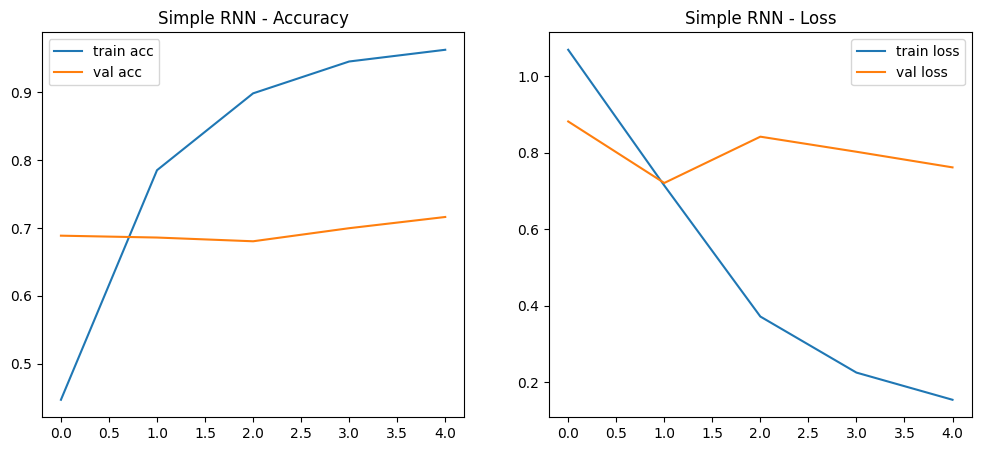

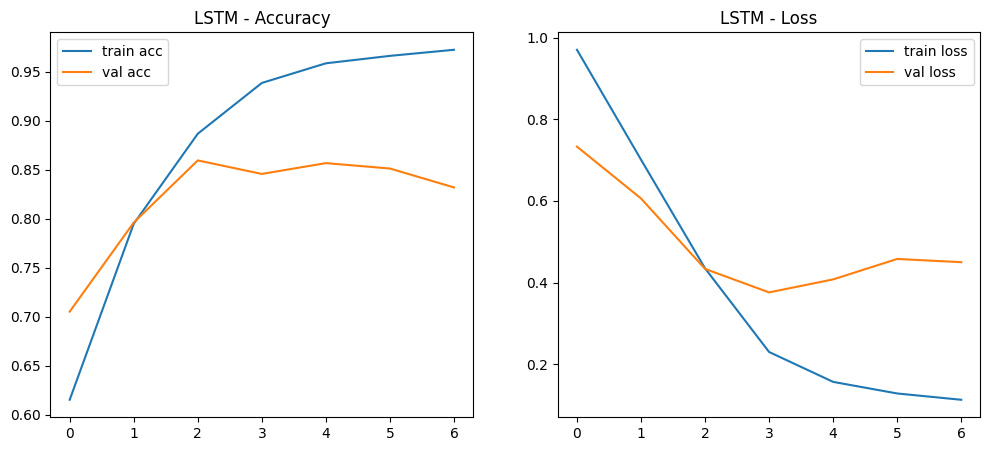

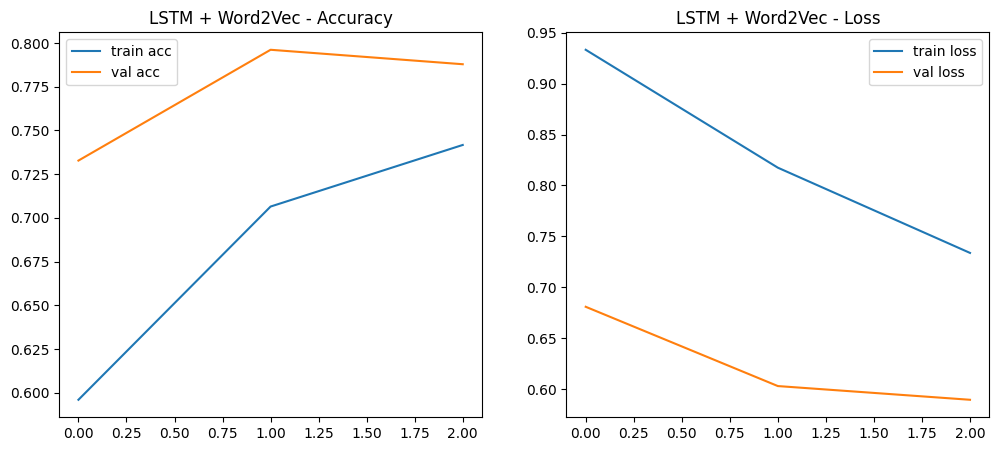

In [103]:
# Visualization of Training vs Validation Metrics
def plot_history(history, title):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='train acc')
    plt.plot(history.history['val_accuracy'], label='val acc')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')
    plt.title(f'{title} - Loss')
    plt.legend()

    plt.show()

plot_history(history1, "Simple RNN")
plot_history(history2, "LSTM")
plot_history(history3, "LSTM + Word2Vec")

**Model Training and Evaluation:**

Evaluating Model 1 - Simple RNN
Test Accuracy: 0.6976

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.30      0.34      0.32        56
           1       0.86      0.86      0.86       276
           2       0.53      0.50      0.51       121

    accuracy                           0.70       453
   macro avg       0.56      0.56      0.56       453
weighted avg       0.70      0.70      0.70       453

Confusion Matrix:


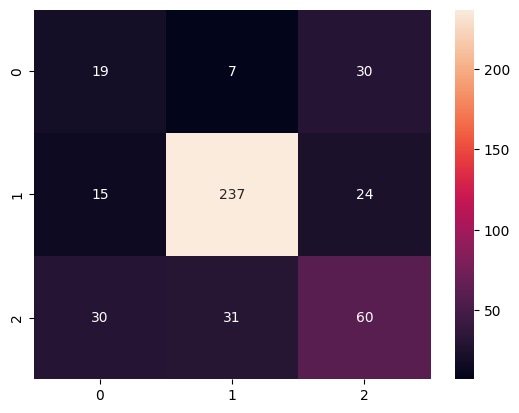

Evaluating Model 2 - LSTM
Test Accuracy: 0.8344

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.73      0.67        56
           1       0.90      0.93      0.92       276
           2       0.78      0.66      0.72       121

    accuracy                           0.83       453
   macro avg       0.77      0.77      0.77       453
weighted avg       0.84      0.83      0.83       453

Confusion Matrix:


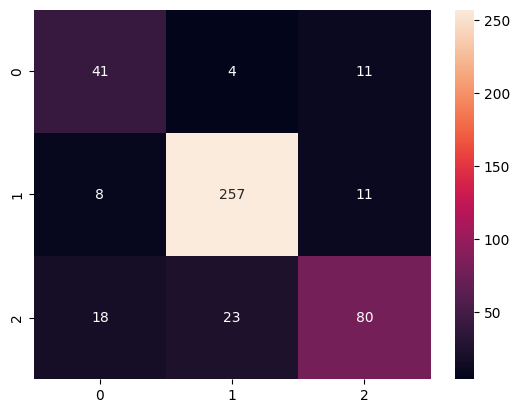

Evaluating Model 3 - LSTM + Word2Vec
Test Accuracy: 0.7108

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.38      0.55      0.45        56
           1       0.87      0.87      0.87       276
           2       0.53      0.43      0.47       121

    accuracy                           0.71       453
   macro avg       0.60      0.62      0.60       453
weighted avg       0.72      0.71      0.71       453

Confusion Matrix:


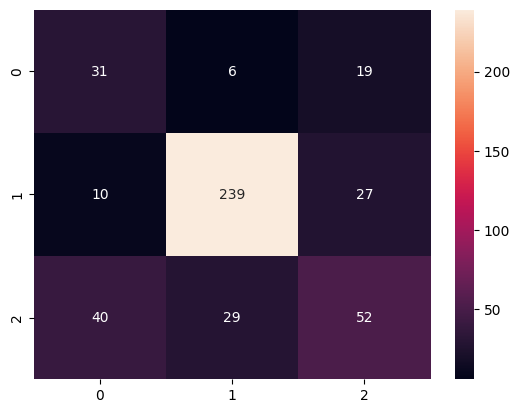

In [104]:
# Model Evaluation
def evaluate_model(model, X_test_pad, y_test_encoded):
    loss, acc = model.evaluate(X_test_pad, y_test_encoded, verbose=0) # Get test accuracy
    print(f"Test Accuracy: {acc:.4f}\n")

    y_pred = model.predict(X_test_pad) # Get predictions
    y_pred_classes = np.argmax(y_pred, axis=1) # Convert to class labels
    y_true_classes = np.argmax(y_test_encoded, axis=1) # Convert true labels

    print("Classification Report:\n", classification_report(y_true_classes, y_pred_classes))
    print("Confusion Matrix:")
    sns.heatmap(confusion_matrix(y_true_classes, y_pred_classes), annot=True, fmt='d')
    plt.show()

# Evaluate all three models
print("Evaluating Model 1 - Simple RNN")
evaluate_model(model1, X_test_pad, y_test_encoded)

print("Evaluating Model 2 - LSTM")
evaluate_model(model2, X_test_pad, y_test_encoded)

print("Evaluating Model 3 - LSTM + Word2Vec")
evaluate_model(model3, X_test_pad, y_test_encoded)

In [105]:
# Save Models and Preprocessing Objects
model1.save("model_rnn.keras")
model2.save("model_lstm.keras")
model3.save("model_lstm_word2vec.keras")

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("All models and preprocessing objects saved successfully!")

All models and preprocessing objects saved successfully!


**Error Analysis:**

In [106]:
# Get predictions from Model 2
y_pred_probs = model2.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_encoded, axis=1)

# Find misclassified indices
misclassified_idx = np.where(y_pred != y_true)[0]

# Create label mapping
label_map = dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_))

# Show 3 incorrect predictions as required
print("Misclassified Examples (3 Incorrect Predictions)")

for i in range(3):
    idx = misclassified_idx[i]
    print(f"\nExample {i+1}:")
    print(f"Text: {X_test[idx]}")
    print(f"True Label: {label_map[y_true[idx]]}")
    print(f"Predicted Label: {label_map[y_pred[idx]]}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Misclassified Examples (3 Incorrect Predictions)

Example 1:
Text: ebit margin
True Label: positive
Predicted Label: negative

Example 2:
Text: accord post world intellectual property organization present invention relate hydrocarbons particularly manufacture hydrocarbon components suitable aviation fuel jet fuel blend stock aviation fuel
True Label: neutral
Predicted Label: positive

Example 3:
Text: company expect net sales whole eur mn mn
True Label: neutral
Predicted Label: negative


In [107]:
# Model Complexity vs Performance Analysis
print("Model Complexity VS Performance Analysis")

models_info = [
    ("Simple RNN", model1, 128, 64),
    ("LSTM", model2, 128, 64),
    ("LSTM + Word2Vec", model3, 300, 64)
]

# Evaluate each model's accuracy and parameters
for name, model, emb_dim, units in models_info:
    y_pred_temp = np.argmax(model.predict(X_test_pad), axis=1)
    y_true_temp = np.argmax(y_test_encoded, axis=1)
    acc_temp = np.mean(y_pred_temp == y_true_temp)

    print(f"\n{name}:")
    print(f"  - Embedding Dimension: {emb_dim}")
    print(f"  - Recurrent Units: {units}")
    print(f"  - Trainable Parameters: {model.count_params():,}")
    print(f"  - Test Accuracy: {acc_temp:.4f}")

Model Complexity VS Performance Analysis
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Simple RNN:
  - Embedding Dimension: 128
  - Recurrent Units: 64
  - Trainable Parameters: 1,084,931
  - Test Accuracy: 0.6976
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

LSTM:
  - Embedding Dimension: 128
  - Recurrent Units: 64
  - Trainable Parameters: 1,232,771
  - Test Accuracy: 0.8344
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

LSTM + Word2Vec:
  - Embedding Dimension: 300
  - Recurrent Units: 64
  - Trainable Parameters: 1,433,235
  - Test Accuracy: 0.7108


**Possible Reasons for Errors (Financial Sentiment)**

Imbalanced data: There are many more neutral examples than positive or negative ones, which can bias the model.

Confusing language: Financial words can mean different things depending on context.

Mixed emotions: Some sentences contain both positive and negative signals, making them harder to classify.

Not enough context: Short texts don’t provide enough information for accurate prediction.

Overfitting: The model may have memorized the training data instead of learning general patterns.

**Suggested Improvements**

Use class weights to handle uneven class distribution.

Add more examples, especially for positive and negative cases.

Apply dropout and regularization to reduce overfitting.

Try a BiLSTM model to understand context from both directions.

Use pre-trained financial embeddings like FinBERT for better understanding of financial language.

Use cross-validation for more reliable evaluation.

**GUI for Real Time Prediction:**

In [108]:
model = load_model("model_lstm.keras")

# Load tokenizer and label encoder
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

with open("label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

max_len = 28

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Cleaning function
def clean_financial_text(text):
    # Lowercase
    text = text.lower()

    # Remove URLs, mentions, hashtags, numbers
    text = re.sub(r'http\S+|www\S+|@\w+|#\w+|\d+', '', text)

    # Handle contractions
    text = contractions.fix(text)

    # Remove emojis
    emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"
                           u"\U0001F300-\U0001F5FF"
                           u"\U0001F680-\U0001F6FF"
                           u"\U0001F1E0-\U0001F1FF"
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r' ', text)

    # Remove punctuation and special characters
    tokenizer_punct = RegexpTokenizer(r"\w+")
    tokens = tokenizer_punct.tokenize(text)
    text = ' '.join(tokens)

    # Remove stopwords
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatize (using 'v' pos as in training)
    tokens = [lemmatizer.lemmatize(token, pos='v') for token in tokens]

    return ' '.join(tokens)

def predict_sentiment(financial_text):
    if not financial_text.strip():
        return "Please enter some text to analyze."

    # Clean the text
    cleaned = clean_financial_text(financial_text)

    # Convert to sequence
    seq = tokenizer.texts_to_sequences([cleaned])

    # Check if sequence is empty
    if len(seq[0]) == 0:
        return "No recognizable words found. Please try a different phrase."

    # Pad sequence
    padded = pad_sequences(seq, maxlen=max_len, padding='pre')

    # Predict
    prediction = model.predict(padded, verbose=0)
    pred_class = np.argmax(prediction, axis=1)[0]

    # Get actual label name
    sentiment = label_encoder.inverse_transform([pred_class])[0]

    # Return result
    return sentiment.upper()

# GUI
iface = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=4, placeholder="Enter financial news text here...", label="Financial Text"),
    outputs=gr.Textbox(label="Sentiment Prediction"),
    title="Financial Sentiment Analyzer",
    description="Classifies financial news/text as POSITIVE, NEGATIVE, or NEUTRAL sentiment.",
    theme="soft"
)

iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9f7f1f943750a382e0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
